<a href="https://colab.research.google.com/github/JonHemrick/ECGR4106/blob/HW1/HW1_Prob1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


seed = 42
torch.manual_seed(seed)
np.random.seed(seed)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [9]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])


train_data_augmented = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

train_data_clean = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_test
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_size = 45000
val_size = 5000

indices = torch.randperm(50000, generator=torch.Generator().manual_seed(seed))

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = torch.utils.data.Subset(train_data_augmented, train_indices)
val_dataset = torch.utils.data.Subset(train_data_clean, val_indices)

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

class_names = train_data_augmented.classes

print(class_names)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training images: 45000
Validation images: 5000
Test images: 10000


In [10]:
class ModifiedAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ModifiedAlexNet, self).__init__()

        self.features = nn.Sequential(
            # Input: 3 x 32 x 32
            nn.Conv2d(3, 64, kernel_size=3, padding=1),     # 64 x 32 x 32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 64 x 16 x 16

            nn.Conv2d(64, 192, kernel_size=3, padding=1),   # 192 x 16 x 16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 192 x 8 x 8

            nn.Conv2d(192, 384, kernel_size=3, padding=1),  # 384 x 8 x 8
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),  # 256 x 8 x 8
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),  # 256 x 8 x 8
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)           # 256 x 4 x 4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = ModifiedAlexNet(num_classes=10).to(device)
print(model)

ModifiedAlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(

In [11]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Modified AlexNet trainable parameters: {total_params:,}")
print("Original AlexNet parameters: approximately 61,000,000")
print(f"Parameter reduction factor: {61000000 / total_params:.2f}x smaller")

Modified AlexNet trainable parameters: 4,483,146
Original AlexNet parameters: approximately 61,000,000
Parameter reduction factor: 13.61x smaller


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 30

print("Hyperparameters:")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Batch size:", batch_size)
print("Epochs:", num_epochs)
print("Loss function: CrossEntropyLoss")
print("Random seed:", seed)

Hyperparameters:
Optimizer: Adam
Learning rate: 0.001
Batch size: 128
Epochs: 30
Loss function: CrossEntropyLoss
Random seed: 42


In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Track loss
        running_loss += loss.item() * images.size(0)

        # Track accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [14]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/30] Train Loss: 1.8106 Train Acc: 0.3129 Val Loss: 1.4638 Val Acc: 0.4490
Epoch [2/30] Train Loss: 1.3454 Train Acc: 0.5049 Val Loss: 1.1702 Val Acc: 0.5762
Epoch [3/30] Train Loss: 1.1315 Train Acc: 0.5927 Val Loss: 0.9873 Val Acc: 0.6548
Epoch [4/30] Train Loss: 0.9742 Train Acc: 0.6553 Val Loss: 0.9067 Val Acc: 0.6818
Epoch [5/30] Train Loss: 0.8595 Train Acc: 0.6978 Val Loss: 0.8138 Val Acc: 0.7092
Epoch [6/30] Train Loss: 0.7806 Train Acc: 0.7272 Val Loss: 0.7460 Val Acc: 0.7328
Epoch [7/30] Train Loss: 0.7184 Train Acc: 0.7472 Val Loss: 0.7102 Val Acc: 0.7538
Epoch [8/30] Train Loss: 0.6672 Train Acc: 0.7662 Val Loss: 0.6541 Val Acc: 0.7688
Epoch [9/30] Train Loss: 0.6339 Train Acc: 0.7786 Val Loss: 0.6458 Val Acc: 0.7700
Epoch [10/30] Train Loss: 0.6024 Train Acc: 0.7913 Val Loss: 0.6296 Val Acc: 0.7854
Epoch [11/30] Train Loss: 0.5677 Train Acc: 0.8022 Val Loss: 0.6008 Val Acc: 0.7926
Epoch [12/30] Train Loss: 0.5417 Train Acc: 0.8111 Val Loss: 0.5654 Val Acc: 0.8060
E

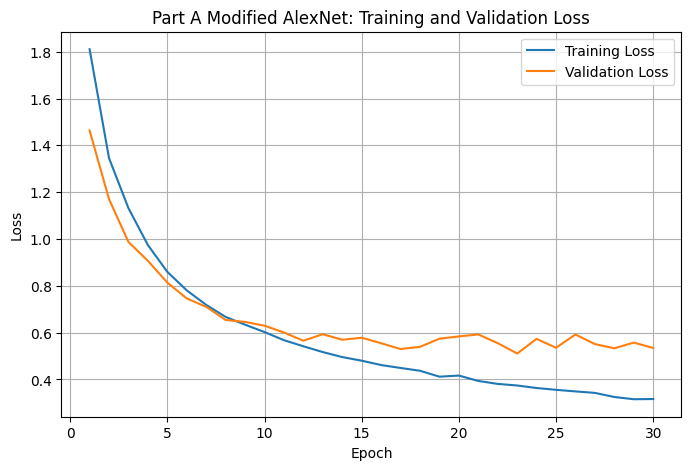

In [15]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part A Modified AlexNet: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

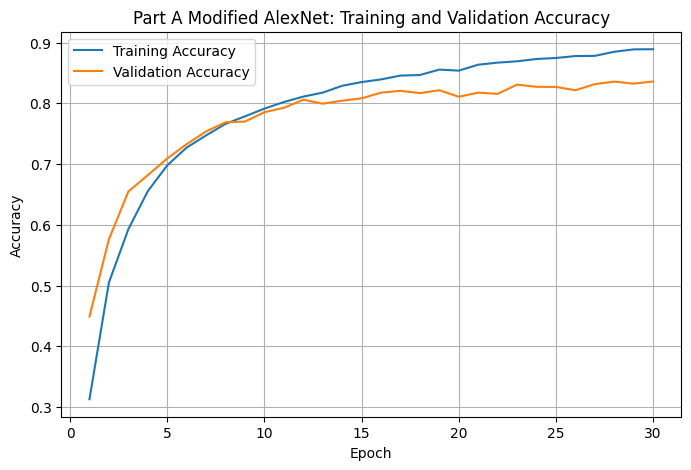

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Part A Modified AlexNet: Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
test_loss, test_acc = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

Final Test Loss: 0.5398
Final Test Accuracy: 82.76%


<Figure size 1000x1000 with 0 Axes>

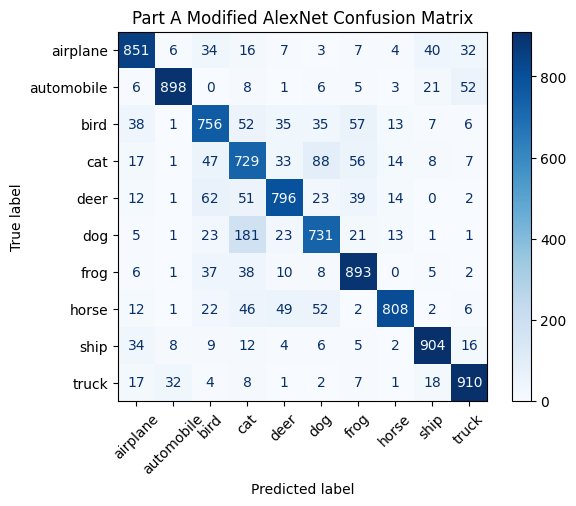

In [18]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Part A Modified AlexNet Confusion Matrix")
plt.show()

First conv layer weight shape: torch.Size([64, 3, 3, 3])


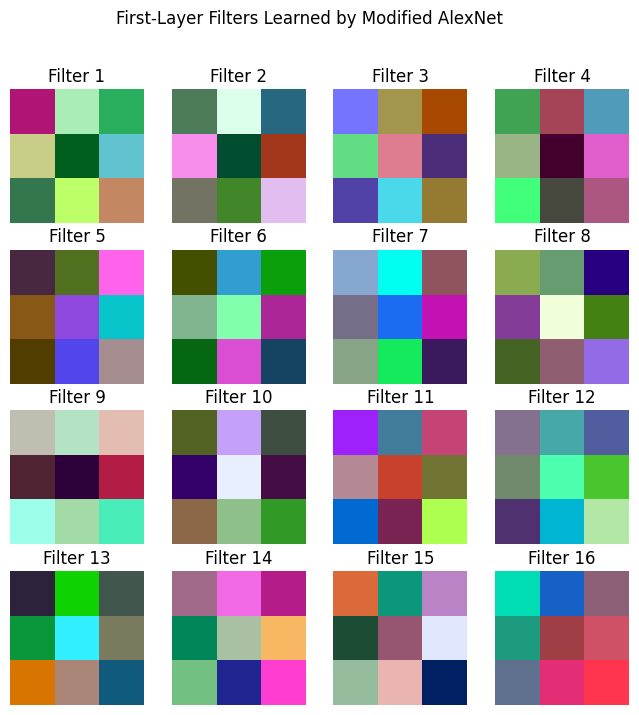

In [19]:

first_conv_weights = model.features[0].weight.data.cpu()


print("First conv layer weight shape:", first_conv_weights.shape)

# Normalize filters for visualization
def normalize_filter(img):
    img = img - img.min()
    img = img / img.max()
    return img

num_filters_to_show = min(16, first_conv_weights.shape[0])

plt.figure(figsize=(8, 8))

for i in range(num_filters_to_show):
    filt = first_conv_weights[i]

    # Convert from C x H x W to H x W x C
    filt = filt.permute(1, 2, 0)

    filt = normalize_filter(filt)

    plt.subplot(4, 4, i + 1)
    plt.imshow(filt)
    plt.axis("off")
    plt.title(f"Filter {i+1}")

plt.suptitle("First-Layer Filters Learned by Modified AlexNet")
plt.show()

In [20]:
torch.save(model.state_dict(), "part_a_modified_alexnet_cifar10.pth")


Model saved as part_a_modified_alexnet_cifar10.pth


PART B

In [21]:
class ModifiedAlexNetDropout(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super(ModifiedAlexNetDropout, self).__init__()

        self.features = nn.Sequential(
            # Input: 3 x 32 x 32
            nn.Conv2d(3, 64, kernel_size=3, padding=1),     # 64 x 32 x 32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 64 x 16 x 16

            nn.Conv2d(64, 192, kernel_size=3, padding=1),   # 192 x 16 x 16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),          # 192 x 8 x 8

            nn.Conv2d(192, 384, kernel_size=3, padding=1),  # 384 x 8 x 8
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),  # 256 x 8 x 8
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),  # 256 x 8 x 8
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)           # 256 x 4 x 4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [22]:
def run_dropout_experiment(dropout_rate, num_epochs=30):
    print(f"\nTraining Modified AlexNet with Dropout p = {dropout_rate}\n")


    model = ModifiedAlexNetDropout(
        num_classes=10,
        dropout_rate=dropout_rate
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.4f}"
        )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    print(f"\nDropout p = {dropout_rate}")
    print(f"Final Test Loss: {test_loss:.4f}")
    print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

    results = {
        "dropout_rate": dropout_rate,
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "test_loss": test_loss,
        "test_acc": test_acc
    }

    return results

In [23]:
dropout_03_results = run_dropout_experiment(
    dropout_rate=0.3,
    num_epochs=30
)


Training Modified AlexNet with Dropout p = 0.3

Epoch [1/30] Train Loss: 1.8312 Train Acc: 0.3033 Val Loss: 1.5360 Val Acc: 0.4284
Epoch [2/30] Train Loss: 1.4017 Train Acc: 0.4849 Val Loss: 1.2263 Val Acc: 0.5554
Epoch [3/30] Train Loss: 1.1924 Train Acc: 0.5714 Val Loss: 1.0253 Val Acc: 0.6342
Epoch [4/30] Train Loss: 1.0510 Train Acc: 0.6287 Val Loss: 0.9480 Val Acc: 0.6586
Epoch [5/30] Train Loss: 0.9534 Train Acc: 0.6680 Val Loss: 0.8359 Val Acc: 0.7062
Epoch [6/30] Train Loss: 0.8627 Train Acc: 0.7014 Val Loss: 0.8067 Val Acc: 0.7176
Epoch [7/30] Train Loss: 0.8031 Train Acc: 0.7215 Val Loss: 0.7312 Val Acc: 0.7478
Epoch [8/30] Train Loss: 0.7480 Train Acc: 0.7425 Val Loss: 0.7495 Val Acc: 0.7448
Epoch [9/30] Train Loss: 0.6994 Train Acc: 0.7602 Val Loss: 0.6867 Val Acc: 0.7624
Epoch [10/30] Train Loss: 0.6557 Train Acc: 0.7761 Val Loss: 0.6362 Val Acc: 0.7818
Epoch [11/30] Train Loss: 0.6287 Train Acc: 0.7853 Val Loss: 0.6546 Val Acc: 0.7782
Epoch [12/30] Train Loss: 0.6052 Tra

In [24]:
dropout_05_results = run_dropout_experiment(
    dropout_rate=0.5,
    num_epochs=30
)


Training Modified AlexNet with Dropout p = 0.5

Epoch [1/30] Train Loss: 1.8469 Train Acc: 0.2905 Val Loss: 1.5140 Val Acc: 0.4278
Epoch [2/30] Train Loss: 1.4364 Train Acc: 0.4713 Val Loss: 1.2329 Val Acc: 0.5490
Epoch [3/30] Train Loss: 1.2291 Train Acc: 0.5614 Val Loss: 1.0465 Val Acc: 0.6276
Epoch [4/30] Train Loss: 1.0749 Train Acc: 0.6248 Val Loss: 0.9401 Val Acc: 0.6740
Epoch [5/30] Train Loss: 0.9723 Train Acc: 0.6672 Val Loss: 0.8704 Val Acc: 0.7002
Epoch [6/30] Train Loss: 0.8820 Train Acc: 0.6990 Val Loss: 0.7657 Val Acc: 0.7326
Epoch [7/30] Train Loss: 0.8129 Train Acc: 0.7244 Val Loss: 0.7541 Val Acc: 0.7460
Epoch [8/30] Train Loss: 0.7556 Train Acc: 0.7452 Val Loss: 0.7215 Val Acc: 0.7530
Epoch [9/30] Train Loss: 0.7115 Train Acc: 0.7632 Val Loss: 0.6558 Val Acc: 0.7740
Epoch [10/30] Train Loss: 0.6751 Train Acc: 0.7731 Val Loss: 0.6275 Val Acc: 0.7850
Epoch [11/30] Train Loss: 0.6402 Train Acc: 0.7843 Val Loss: 0.6529 Val Acc: 0.7776
Epoch [12/30] Train Loss: 0.6197 Tra

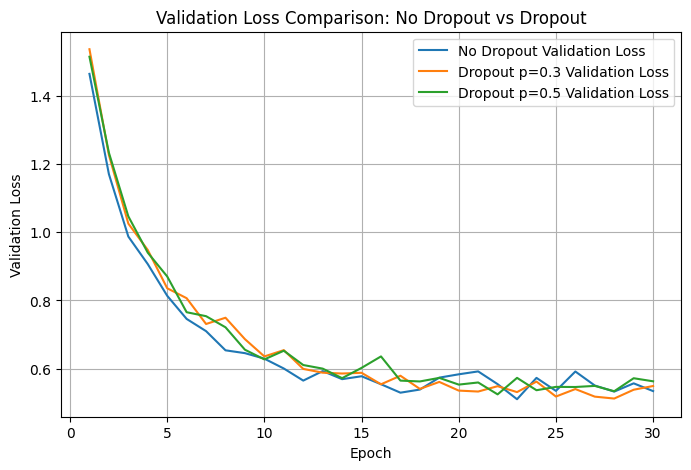

In [25]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_losses,
    label="No Dropout Validation Loss"
)

plt.plot(
    epochs,
    dropout_03_results["val_losses"],
    label="Dropout p=0.3 Validation Loss"
)

plt.plot(
    epochs,
    dropout_05_results["val_losses"],
    label="Dropout p=0.5 Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison: No Dropout vs Dropout")
plt.legend()
plt.grid(True)
plt.show()

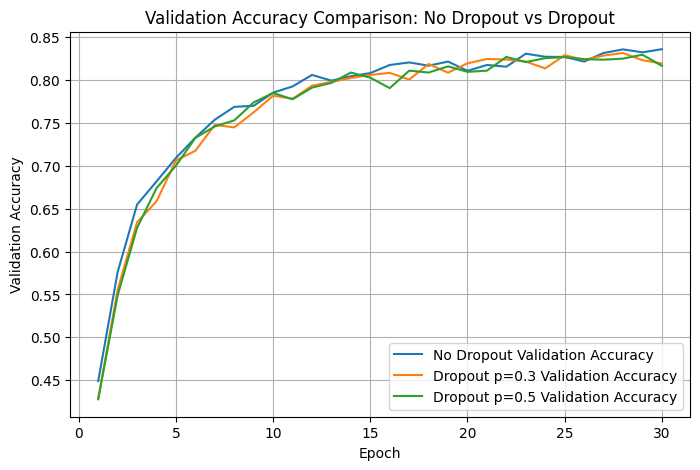

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_accuracies,
    label="No Dropout Validation Accuracy"
)

plt.plot(
    epochs,
    dropout_03_results["val_accuracies"],
    label="Dropout p=0.3 Validation Accuracy"
)

plt.plot(
    epochs,
    dropout_05_results["val_accuracies"],
    label="Dropout p=0.5 Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison: No Dropout vs Dropout")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
results_table = [
    {
        "Model": "No Dropout",
        "Final Train Acc": train_accuracies[-1],
        "Final Val Acc": val_accuracies[-1],
        "Test Acc": test_acc
    },
    {
        "Model": "Dropout p=0.3",
        "Final Train Acc": dropout_03_results["train_accuracies"][-1],
        "Final Val Acc": dropout_03_results["val_accuracies"][-1],
        "Test Acc": dropout_03_results["test_acc"]
    },
    {
        "Model": "Dropout p=0.5",
        "Final Train Acc": dropout_05_results["train_accuracies"][-1],
        "Final Val Acc": dropout_05_results["val_accuracies"][-1],
        "Test Acc": dropout_05_results["test_acc"]
    }
]

for row in results_table:
    print(row)

{'Model': 'No Dropout', 'Final Train Acc': 0.8890888888888889, 'Final Val Acc': 0.836, 'Test Acc': 0.8276}
{'Model': 'Dropout p=0.3', 'Final Train Acc': 0.8662444444444445, 'Final Val Acc': 0.8194, 'Test Acc': 0.8207}
{'Model': 'Dropout p=0.5', 'Final Train Acc': 0.8672666666666666, 'Final Val Acc': 0.8166, 'Test Acc': 0.8212}
